In [14]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

In [10]:
from pathlib import Path
from urllib.request import urlretrieve

FACE_LANDMARKER_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
    "face_landmarker/float16/latest/face_landmarker.task"
)
DEFAULT_MODEL_PATH = Path("./mock-data/models/face_landmarker.task")


def _ensure_face_landmarker_model(model_path):
    model_path = Path(model_path)
    if model_path.exists():
        return str(model_path)

    model_path.parent.mkdir(parents=True, exist_ok=True)
    try:
        urlretrieve(FACE_LANDMARKER_MODEL_URL, model_path)
    except Exception as exc:
        raise RuntimeError(
            "Khong the tai model FaceLandmarker. Hay kiem tra internet hoac dat model thu cong."
        ) from exc

    return str(model_path)


def _detect_with_tasks(image, max_num_faces, model_path):
    model_asset_path = _ensure_face_landmarker_model(model_path or DEFAULT_MODEL_PATH)
    base_options = mp.tasks.BaseOptions(model_asset_path=model_asset_path)
    options = mp.tasks.vision.FaceLandmarkerOptions(
        base_options=base_options,
        num_faces=max_num_faces,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
    )

    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)

    with mp.tasks.vision.FaceLandmarker.create_from_options(options) as landmarker:
        results = landmarker.detect(mp_image)

    landmarks = []
    if results.face_landmarks:
        h, w = image.shape[:2]
        for face_landmarks in results.face_landmarks:
            coords = np.array(
                [[lm.x * w, lm.y * h] for lm in face_landmarks],
                dtype=np.float32,
            )
            landmarks.append(coords)

    return landmarks


def _detect_with_solutions(image, max_num_faces):
    face_mesh_module = mp.solutions.face_mesh
    with face_mesh_module.FaceMesh(
        static_image_mode=True,
        max_num_faces=max_num_faces,
        refine_landmarks=True,
        min_detection_confidence=0.5,
    ) as face_mesh:
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb_image)

        landmarks = []
        if results.multi_face_landmarks:
            h, w = image.shape[:2]
            for face_landmarks in results.multi_face_landmarks:
                coords = np.array(
                    [[lm.x * w, lm.y * h] for lm in face_landmarks.landmark],
                    dtype=np.float32,
                )
                landmarks.append(coords)

        return landmarks


def detect_landmarks_mediapipe(image, max_num_faces=1, model_path=None):
    """Return a list of (N, 2) arrays, one array per detected face."""
    if image is None:
        raise ValueError("image is None. Kiem tra duong dan anh hoac cv2.imread")

    if (
        hasattr(mp, "tasks")
        and hasattr(mp.tasks, "vision")
        and hasattr(mp.tasks.vision, "FaceLandmarker")
    ):
        return _detect_with_tasks(image, max_num_faces=max_num_faces, model_path=model_path)

    if hasattr(mp, "solutions") and hasattr(mp.solutions, "face_mesh"):
        return _detect_with_solutions(image, max_num_faces=max_num_faces)

    raise ImportError(
        "Mediapipe hien tai khong co FaceLandmarker (tasks) hoac FaceMesh (solutions)."
    )

In [19]:
# img = cv2.imread("./mock-data/Surprise_1359028.jpg")
img = cv2.imread("./mock-data/crop_0_200_180_480.png")
points = detect_landmarks_mediapipe(img)

print(f"So khuon mat: {len(points)}")
if points:
    print(f"So landmark cua khuon mat dau tien: {points[0].shape[0]}")

So khuon mat: 1
So landmark cua khuon mat dau tien: 478


W0000 00:00:1776788579.315937  557796 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1776788579.328682  557796 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1776788579.336555  557817 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: Mesa Intel(R) Graphics (MTL)
W0000 00:00:1776788579.343865  557799 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776788579.367520  557810 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [20]:
def visualize_landmarks(image, points_list, face_idx=None, radius=1, color=(0, 255, 0)):
    """
    image: ảnh BGR từ cv2
    points_list: output từ detect_landmarks_mediapipe (list các mảng Nx2)
    face_idx:
      - None: vẽ tất cả khuôn mặt
      - số nguyên: chỉ vẽ 1 khuôn mặt
    """
    if image is None:
        raise ValueError("image is None")

    canvas = image.copy()

    if not points_list:
        print("Không phát hiện khuôn mặt nào.")
    else:
        faces = points_list if face_idx is None else [points_list[face_idx]]
        for pts in faces:
            pts_i = np.round(pts).astype(np.int32)
            for x, y in pts_i:
                cv2.circle(canvas, (x, y), radius, color, -1, lineType=cv2.LINE_AA)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"So khuon mat: {len(points_list)}")
    plt.show()

    return canvas

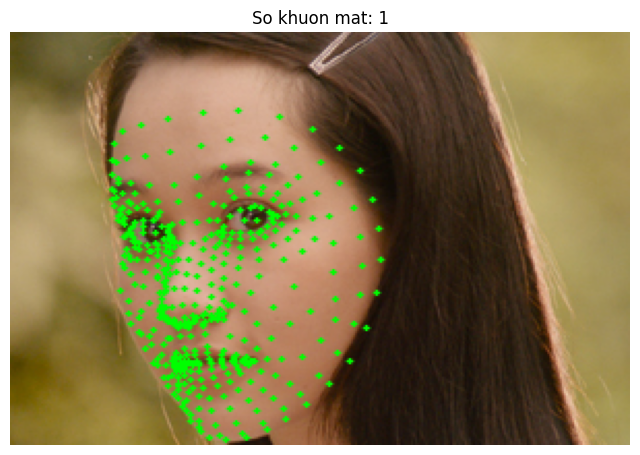

In [21]:
vis = visualize_landmarks(img, points)          # vẽ tất cả khuôn mặt
# vis_one = visualize_landmarks(img, points, 0) # chỉ khuôn mặt đầu tiên